# Refining the hinge weight: does a denser ladder find a real improvement?

`part_3` closed with a negative verdict and three readings that its own design could not
separate. One of them was that the weight grid might be too coarse near $\lambda=10^{-3}$,
which held the only positive point in the whole sweep. This notebook tests that reading
directly on a campaign that fills the interval between $10^{-3}$ and $10^{-2}$ with four
additional weights, and compares the result against the two configurations that survived
`part_2`'s geometry screen untouched.

Everything is restricted to nine cells. The previous notebooks had to plot 28 of them,
which made the region of interest unreadable; here the surviving candidates and their
refinement are the only things on the axes.

## Introduction

Three groups appear below, chosen for distinct reasons:

- the **baseline**, an unregularized model on the same split, as the reference every
  contrast is taken against;
- two **weak-penalty controls**, Fisher-Rao Frobenius and Fisher-Rao spectral at
  $\lambda=10^{-5}$, which `part_1` and `part_2` showed to be indistinguishable from the
  baseline on both prediction and geometry. They are included as a null band: whatever
  spread they show is what "no effect" looks like in this design;
- the **hinge weight ladder**, Fisher-Rao spectral-plus-hinge at
  $\lambda \in \{1, 2, 4, 6, 8\}\times10^{-3}$ and $10^{-2}$. The endpoints come from the
  earlier campaign and the four interior points from the new one, so the ladder is
  continuous across the interval where the earlier sweep had a single sample.

The question is narrow and pre-stated: does average precision along this ladder rise above
the baseline anywhere, by more than the null band's own spread, and does the latent
geometry stay intact where it does.

### Assumptions

- **The two campaigns are poolable on this ladder.** The new campaign shares the
  architecture, binning, subset, split strategy, seeds, head configuration, penalty metric,
  input geometry, penalized space, hinge threshold and hinge alpha with the earlier one.
  Only the objective weight differs. This is checked explicitly below rather than assumed,
  because the ladder's interpretation collapses if any other parameter moved with it.
- **The endpoints are not re-trained.** The $10^{-3}$ and $10^{-2}$ rungs are the earlier
  campaign's models, so a systematic difference between the campaigns, for example a
  library or driver change on the compute node, would appear as a discontinuity at the
  ladder's ends rather than as a trend. The health and cost checks from `part_0_2` are
  repeated for the new campaign for that reason.
- **This is a second look at the same question on the same data.** The interval was chosen
  because the first sweep's best point fell in it, so a positive finding here is a
  selected-region result and its interval is optimistic. It would need an independent
  confirmation before being treated as established.
- **Latent statistics are capped in row count, prediction metrics are not.** Two of the
  latent measures build a pixel-by-pixel matrix and are quadratic in the row count, so they
  run on at most the evaluation split's number of rows, drawn once and shared by every model
  and split. The evaluation split is therefore used whole, while the larger training split
  is summarized on a matched-size subsample. Prediction metrics use both splits complete.
- **Five repetitions per rung bound seed noise only**, for this dataset and split.

### Notation

Notation follows `part_1` and `part_2`. The model maps a binned spectrum
$x \in \mathbb{R}^{M}$ to a latent code and a head score,
$x \xrightarrow{\mathrm{Enc}} z \xrightarrow{h} s$, with $u=(z-\beta)/\gamma$ the
canonicalized code. A cell is $c=(\text{geometry},\text{penalty metric},\lambda)$ with
repetitions $r=0,\dots,4$; $\Sigma=\operatorname{Cov}(u)$ and its trace measures retained
latent variation.

In [1]:
import hashlib
import json
import os
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from scipy import stats

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader import read_entropy_campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import penalty_sweep as sweep
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import sweep_evaluation as evaluation
from msi_autoencoder_wrapper.analysis.autoencoder.latent import sphere_geometry as geometry
from msi_autoencoder_wrapper.utils.logger import get_custom_logger
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

logger = get_custom_logger("hinge_activation_refinement")

2026-09-07 17:40:33,658 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-07 17:40:33,662 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-07 17:40:33,756 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-07 17:40:33,757 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 23 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-07 17:40:33,760 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-07 17:40:33,762 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-07 17:40:33,779 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-09-07 17:40:33,907 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 21 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-09-07 17:40:33,909 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 25 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Configuration and the nine selected cells

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
MODEL_STORE = WORKSPACE / "models" / MODEL_CONTEXT

ACTIVATION_CAMPAIGN = "fisher-rao-hinge-activation-20260907-01"
FISHER_CAMPAIGN = "fischer-rao-spectral-hinge-experiment-20260906-01"
BASELINE_CAMPAIGN = "bce-baseline-20260905-01"
CAMPAIGNS = [ACTIVATION_CAMPAIGN, FISHER_CAMPAIGN, BASELINE_CAMPAIGN]

BASELINE_CELL = "baseline (no contractive)"
CONTROL_CELLS = [
    "fisher_rao / frobenius / w=1e-05",
    "fisher_rao / spectral / w=1e-05",
]
LADDER_CELLS = [
    "fisher_rao / spectral_plus_hinged / w=1e-03 / tau=7",
    "fisher_rao / spectral_plus_hinged / w=2e-03 / tau=7",
    "fisher_rao / spectral_plus_hinged / w=4e-03 / tau=7",
    "fisher_rao / spectral_plus_hinged / w=6e-03 / tau=7",
    "fisher_rao / spectral_plus_hinged / w=8e-03 / tau=7",
    "fisher_rao / spectral_plus_hinged / w=1e-02 / tau=7",
]
SELECTED_CELLS = [BASELINE_CELL, *CONTROL_CELLS, *LADDER_CELLS]

HEAD_NAME = "molecule_primary"
TARGET_FIELD = "molecule"
THRESHOLD = 0.5
BATCH_SIZE = 256
PIXEL_FRACTION = 1.0
SAMPLE_SEED = 42
PAIR_COUNT = 5000
KNN_NEIGHBORS = 10
# Two of the latent statistics build an (N, N) matrix, so the row count is capped.
# Set to the evaluation split's size below, once the splits are materialized.
GEOMETRY_SAMPLE = None
EPSILONS = (0.001, 0.003, 0.01, 0.03, 0.1)
DECODE_CACHE = Path("data/kidney_workspace/cache/materialized_splits")

ARTIFACT_DIR = Path("assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/part_4_hinge_activation_refinement_results")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

theme = resolve_theme(None)
theme.apply()

all_grid_rows, dynamics_rows = [], []
for campaign_id in CAMPAIGNS:
    status = WORKSPACE / "configs" / "entropy-runs" / campaign_id / "plan" / "status"
    tasks = read_entropy_campaign(status, MODEL_STORE, load_artifacts=True)
    all_grid_rows += sweep.sweep_grid_frame(tasks, campaign_id)
    dynamics_rows += sweep.training_dynamics_frame(tasks, campaign_id)

grid_frame = pd.DataFrame(
    [row for row in all_grid_rows if row["status"] == "completed" and row["cell_label"] in SELECTED_CELLS]
)
missing = sorted(set(SELECTED_CELLS) - set(grid_frame["cell_label"]))
if missing:
    raise KeyError(f"Selected cells absent from the campaigns: {missing}")
print(f"{len(grid_frame)} run(s) across {grid_frame['cell_label'].nunique()} selected cell(s)")
display(grid_frame.groupby(["campaign", "cell_label"]).size().rename("runs"))

2026-09-07 17:40:34,069 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:71 | Reading 20 entropy task manifest(s) from 'data/kidney_workspace/configs/entropy-runs/fisher-rao-hinge-activation-20260907-01/plan/status'.


2026-09-07 17:40:34,631 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:97 | Entropy campaign at 'data/kidney_workspace/configs/entropy-runs/fisher-rao-hinge-activation-20260907-01/plan/status': 20 task(s) read.


2026-09-07 17:40:34,632 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:230 | Campaign 'fisher-rao-hinge-activation-20260907-01': 20 task(s), 20 completed, 4 distinct grid cell(s).


2026-09-07 17:40:34,637 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:318 | Campaign 'fisher-rao-hinge-activation-20260907-01': built 2400 per-epoch objective row(s) from 20 task(s).


2026-09-07 17:40:34,639 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:71 | Reading 75 entropy task manifest(s) from 'data/kidney_workspace/configs/entropy-runs/fischer-rao-spectral-hinge-experiment-20260906-01/plan/status'.


...

2026-09-07 17:40:37,040 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:97 | Entropy campaign at 'data/kidney_workspace/configs/entropy-runs/bce-baseline-20260905-01/plan/status': 5 task(s) read.


2026-09-07 17:40:37,133 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:230 | Campaign 'bce-baseline-20260905-01': 5 task(s), 5 completed, 1 distinct grid cell(s).


2026-09-07 17:40:37,135 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:318 | Campaign 'bce-baseline-20260905-01': built 450 per-epoch objective row(s) from 5 task(s).


45 run(s) across 9 selected cell(s)


campaign                                           cell_label                                         
bce-baseline-20260905-01                           baseline (no contractive)                              5
fischer-rao-spectral-hinge-experiment-20260906-01  fisher_rao / frobenius / w=1e-05                       5
                                                   fisher_rao / spectral / w=1e-05                        5
                                                   fisher_rao / spectral_plus_hinged / w=1e-02 / tau=7    5
                                                   fisher_rao / spectral_plus_hinged / w=1e-03 / tau=7    5
fisher-rao-hinge-activation-20260907-01            fisher_rao / spectral_plus_hinged / w=2e-03 / tau=7    5
                                                   fisher_rao / spectral_plus_hinged / w=4e-03 / tau=7    5
                                                   fisher_rao / spectral_plus_hinged / w=6e-03 / tau=7    5
                                 

## Are the ladder's rungs comparable?

### Methodology

#### Theoretical

The ladder spans two campaigns, so before any trend is read across it the rungs must be
shown to differ in the objective weight and in nothing else. If a second parameter moved
with the weight, an apparent trend would be uninterpretable: it could belong to either
factor and the design cannot separate them.

The check is exhaustive rather than sampled. Every recorded penalty parameter other than
the weight is collected across the ladder's rungs, and each is required to take exactly one
value.

#### Implementation

`sweep_cell` resolves each task's penalty configuration from its own status manifest,
falling back to the `ContractiveLoss` constructor defaults for parameters a campaign
predates. The comparison uses those resolved values, not the campaign configuration files,
so a discrepancy between what was configured and what was recorded would surface here.

#### Figure descriptions

The table lists, per penalty parameter, the distinct values it takes across the ladder's
six rungs. A comparable ladder has exactly one value in every row except the weight, which
must have six. Any other row with more than one value invalidates reading the ladder as a
weight trend.

### Remarks

### Notes

In [3]:
ladder_frame = grid_frame[grid_frame["cell_label"].isin(LADDER_CELLS)]
INVARIANT_PARAMETERS = [
    "input_geometry", "penalty_metric", "hinge_threshold", "hinge_alpha",
    "penalized_space", "calculation_method",
]
comparability = pd.DataFrame(
    [
        {
            "parameter": parameter,
            "distinct_values": ladder_frame[parameter].nunique(dropna=False),
            "values": sorted(map(str, ladder_frame[parameter].dropna().unique())),
        }
        for parameter in [*INVARIANT_PARAMETERS, "weight"]
    ]
)
display(comparability)

varying = comparability.query("parameter != 'weight' and distinct_values > 1")
if len(varying):
    raise ValueError(f"Ladder rungs differ in more than the weight: {list(varying['parameter'])}")
print(f"Ladder is a pure weight sweep over {comparability.query('parameter == \"weight\"').iloc[0].distinct_values} rungs.")

,parameter,distinct_values,values
0,input_geometry,1,[fisher_rao]
1,penalty_metric,1,[spectral_plus_hinged]
2,hinge_threshold,1,[7.0]
3,hinge_alpha,1,[2.0]
4,penalized_space,1,[u]
5,calculation_method,1,[exact_autograd_jacobian]
6,weight,6,"[0.001, 0.002, 0.004, 0.006, 0.008, 0.01]"


Ladder is a pure weight sweep over 6 rungs.


## Training validity and cost of the new campaign

### Methodology

#### Theoretical

`part_0_2` established that every run of the earlier campaigns trained cleanly. The new
campaign has not been through that check, and its runs supply four of the ladder's six
rungs, so the same four failure modes are re-tested here: a non-finite objective at any
epoch, a contractive term that grew rather than fell, fewer epochs than the configured
budget, and no improving checkpoint after the first epoch.

Cost is re-measured for the same reason it was measured before: a refinement that lands in
an expensive region of the configuration space is worth less than the same result in a
cheap one. Since the ladder is a pure weight sweep and the weight cannot affect compute,
epoch duration must be flat across it; a departure would indicate the measurement is
picking up machine contention rather than algorithmic cost.

#### Implementation

`training_health_report` and `run_duration_frame` are applied to the pooled per-epoch
records of all three campaigns, then restricted to the selected cells. Durations are
deduplicated on `(model_name, epoch)` before reduction, since the per-epoch records carry
one row per objective term.

#### Figure descriptions

The first table counts flagged runs per campaign, one column per check plus the count
passing all four; zeros and a healthy count equal to the run count is the passing outcome.
The second reports mean epoch duration per selected cell with its spread across runs, and
the ratio to the baseline's mean epoch duration.

### Remarks

### Notes

In [4]:
health_frame = pd.DataFrame(sweep.training_health_report(dynamics_rows, all_grid_rows, planned_epochs=15))
selected_health = health_frame[health_frame["cell_label"].isin(SELECTED_CELLS)]
check_columns = ["non_finite_objectives", "penalty_increased", "short_run", "no_improvement", "healthy"]
display(selected_health.groupby("campaign")[check_columns].sum())

unhealthy = selected_health[~selected_health["healthy"]]
if len(unhealthy):
    display(unhealthy[["campaign", "cell_label", "repetition", "epochs", "first_penalty", "final_penalty", *check_columns[:-1]]])
else:
    print(f"All {len(selected_health)} selected run(s) passed every check.")

run_frame = pd.DataFrame(sweep.run_duration_frame(dynamics_rows))
selected_runs = run_frame[run_frame["cell_label"].isin(SELECTED_CELLS)]
baseline_epoch_seconds = float(selected_runs.query("penalty_metric == 'none'")["mean_epoch_duration"].mean())
duration_summary = (
    selected_runs.groupby("cell_label")
    .agg(
        mean_epoch_seconds=("mean_epoch_duration", "mean"),
        std_epoch_seconds=("mean_epoch_duration", "std"),
        mean_total_seconds=("total_duration", "mean"),
        runs=("model_name", "size"),
    )
    .reindex(SELECTED_CELLS)
)
duration_summary["times_baseline"] = duration_summary["mean_epoch_seconds"] / baseline_epoch_seconds
display(duration_summary.round(2))

2026-09-07 17:40:37,182 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:682 | All 100 run(s) passed the training health checks.


,non_finite_objectives,penalty_increased,short_run,no_improvement,healthy
campaign,,,,,
bce-baseline-20260905-01,0,0,0,0,5
fischer-rao-spectral-hinge-experiment-20260906-01,0,0,0,0,20
fisher-rao-hinge-activation-20260907-01,0,0,0,0,20


All 45 selected run(s) passed every check.
2026-09-07 17:40:37,196 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:433 | Reduced per-epoch rows to 100 run duration record(s).


,mean_epoch_seconds,std_epoch_seconds,mean_total_seconds,runs,times_baseline
cell_label,,,,,
baseline (no contractive),28.40,1.45,426.00,5,1.00
fisher_rao / frobenius / w=1e-05,90.42,6.30,1356.32,5,3.18
fisher_rao / spectral / w=1e-05,60.30,3.55,904.48,5,2.12
fisher_rao / spectral_plus_hinged / w=1e-03 / tau=7,61.40,3.95,920.97,5,2.16
fisher_rao / spectral_plus_hinged / w=2e-03 / tau=7,63.53,4.40,952.93,5,2.24
fisher_rao / spectral_plus_hinged / w=4e-03 / tau=7,62.51,4.00,937.67,5,2.20
fisher_rao / spectral_plus_hinged / w=6e-03 / tau=7,62.11,3.54,931.71,5,2.19
fisher_rao / spectral_plus_hinged / w=8e-03 / tau=7,61.26,3.74,918.94,5,2.16
fisher_rao / spectral_plus_hinged / w=1e-02 / tau=7,66.86,4.19,1002.86,5,2.35


## Evaluating the nine cells

### Methodology

#### Theoretical

Prediction and latent geometry are measured on the same forward passes so that the two
axes describe exactly the same model states. Both splits are evaluated: the evaluation
split answers the question of interest, and the training split supplies the generalization
gap, which is what a regularizer is supposed to reduce.

#### Implementation

`evaluate_campaign_models` loads each of the 45 runs once and produces long-form prediction
and geometry records from the same encoding. Head metrics are computed as batched tensor
operations over the class axis, which is what makes the complete split tractable. Class
scopes are the two used throughout this campaign: all classes, and the fair scope of
classes with an available positive in both splits.

#### Figure descriptions

The table reports the mean over repetitions of every prediction metric per selected cell,
on the evaluation split within the fair scope. It fixes the numeric level; the
distributions follow below.

### Remarks

### Notes

In [5]:
for campaign_id in (ACTIVATION_CAMPAIGN, FISHER_CAMPAIGN):
    evaluation.link_campaign_scratch_workspace(f"/tmp/ms488923/msi-wrapper/{campaign_id}/workspace", WORKSPACE)

wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)
wrapper.load_configuration(model_name=grid_frame.iloc[0]["model_name"])
partitions = wrapper.active_dataset.create_partitions()

splits = {
    name: evaluation.materialize_split(
        partitions, name, TARGET_FIELD, fraction=PIXEL_FRACTION, seed=SAMPLE_SEED,
        cache_directory=DECODE_CACHE,
    )
    for name in ("train", "test")
}
for name, split in splits.items():
    print(f"{name}: {split.sampled}/{split.total} pixel(s)")

GEOMETRY_SAMPLE = splits["test"].sampled
print(f"latent statistics use at most {GEOMETRY_SAMPLE} row(s) per split")

fair_mask = evaluation.fair_scope_mask(splits["train"], splits["test"])
SCOPES = {evaluation.ALL_CLASSES_SCOPE: None, evaluation.FAIR_SCOPE: fair_mask}


def load_model(model_name: str):
    return wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)

2026-09-07 17:40:37,288 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-09-07 17:40:37,289 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-09-07 17:40:37,290 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-09-07 17:40:37,291 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-07 17:40:37,292 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-09-07 17:41:32,763 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:203 | Mapped annotation index: retained_rows=420649 retained_entries=10495756 coordinate_system=binner.


2026-09-07 17:41:32,898 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:275 | Selected 420649/421955 source spectra after annotation policies.


2026-09-07 17:41:34,838 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.sweep_evaluation:263 | Reusing cached split 'train' (33650 pixels) from data/kidney_workspace/cache/materialized_splits/train_45c152d685c8d562.npz.


2026-09-07 17:41:35,062 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.sweep_evaluation:263 | Reusing cached split 'test' (4205 pixels) from data/kidney_workspace/cache/materialized_splits/test_f4d4be4539fed078.npz.


train: 33650/33650 pixel(s)
test: 4205/4205 pixel(s)
latent statistics use at most 4205 row(s) per split
2026-09-07 17:41:35,135 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.sweep_evaluation:354 | Fair scope: 508/508 class(es) active in train, 508 also active in test.


In [6]:
evaluated = evaluation.evaluate_campaign_models(
    grid_frame.to_dict("records"),
    splits,
    load_model,
    head_name=HEAD_NAME,
    scopes=SCOPES,
    threshold=THRESHOLD,
    batch_size=BATCH_SIZE,
    collect_per_class=False,
    collect_geometry=True,
    geometry_sample_size=GEOMETRY_SAMPLE,
    geometry_seed=SAMPLE_SEED,
)
prediction_frame = pd.DataFrame(evaluated["prediction"])
geometry_frame = pd.DataFrame(evaluated["geometry"])
latent_by_cell = evaluated["latent_by_cell"]
print(f"{len(prediction_frame)} prediction row(s), {len(geometry_frame)} geometry row(s)")

2026-09-07 17:41:35,143 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.sweep_evaluation:791 | Latent geometry on split 'train' uses 4205 of 33650 row(s).


2026-09-07 17:41:35,166 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-07 17:41:35,167 | INFO     | msi_autoencoder_wrapper.models.model_loader:68 | Reconstructing loaded model family 'autoencoder'.


2026-09-07 17:41:35,167 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:173 | Initializing multi-component sub-graph resolution phase for model family: autoencoder


2026-09-07 17:41:35,168 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='encoder' using Strategy='CNNEncoder'.


...

2026-09-07 17:43:52,123 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-09-07 17:43:52,126 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-07 17:43:52,130 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


2026-09-07 17:43:55,189 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.sweep_evaluation:868 | Evaluated 45/45 model(s).


1800 prediction row(s), 450 geometry row(s)


In [7]:
METRIC_ORDER = [
    "average_precision", "roc_auc",
    "macro_f1", "macro_precision", "macro_recall",
    "micro_f1", "micro_precision", "micro_recall",
    "hamming_loss",
]
GROUP_COLOR = {
    "baseline": theme.color_for_model("baseline", 0),
    "control": theme.color_for_model("control", 1),
    "ladder": theme.color_for_model("ladder", 2),
}
def cell_group(cell):
    if cell == BASELINE_CELL:
        return "baseline"
    return "control" if cell in CONTROL_CELLS else "ladder"
CELL_COLOR = {cell: GROUP_COLOR[cell_group(cell)] for cell in SELECTED_CELLS}
SHORT_LABEL = {
    BASELINE_CELL: "baseline",
    "fisher_rao / frobenius / w=1e-05": "frobenius 1e-5",
    "fisher_rao / spectral / w=1e-05": "spectral 1e-5",
    **{cell: f"hinge {cell.split('w=')[1].split(' /')[0]}" for cell in LADDER_CELLS},
}

test_frame = prediction_frame.query("split == 'test'")
display(
    test_frame.query("scope == @evaluation.FAIR_SCOPE")
    .pivot_table(index="cell_label", columns="metric", values="value", aggfunc="mean")
    .reindex(SELECTED_CELLS)[METRIC_ORDER].round(4)
)

metric,average_precision,roc_auc,macro_f1,macro_precision,macro_recall,micro_f1,micro_precision,micro_recall,hamming_loss
cell_label,,,,,,,,,
baseline (no contractive),0.6746,0.9890,0.5921,0.5018,0.8286,0.7980,0.6708,0.9847,0.0246
fisher_rao / frobenius / w=1e-05,0.6735,0.9890,0.5947,0.5044,0.8320,0.7982,0.6713,0.9843,0.0246
fisher_rao / spectral / w=1e-05,0.6763,0.9892,0.5957,0.5055,0.8334,0.7996,0.6732,0.9847,0.0244
fisher_rao / spectral_plus_hinged / w=1e-03 / tau=7,0.6798,0.9893,0.5973,0.5075,0.8325,0.7998,0.6735,0.9846,0.0243
fisher_rao / spectral_plus_hinged / w=2e-03 / tau=7,0.6715,0.9889,0.5921,0.5013,0.8311,0.7972,0.6697,0.9846,0.0247
fisher_rao / spectral_plus_hinged / w=4e-03 / tau=7,0.6780,0.9893,0.5926,0.5015,0.8327,0.7977,0.6704,0.9847,0.0247
fisher_rao / spectral_plus_hinged / w=6e-03 / tau=7,0.6718,0.9886,0.5900,0.4999,0.8270,0.7962,0.6688,0.9836,0.0249
fisher_rao / spectral_plus_hinged / w=8e-03 / tau=7,0.6692,0.9891,0.5909,0.5005,0.8269,0.7981,0.6712,0.9841,0.0246
fisher_rao / spectral_plus_hinged / w=1e-02 / tau=7,0.6730,0.9893,0.5929,0.5030,0.8297,0.7986,0.6717,0.9846,0.0245


## Prediction distributions over the nine cells

### Methodology

#### Theoretical

With nine cells rather than 28, every repetition can be drawn without the axis becoming
unreadable, which is the point of this notebook. The two control cells serve as the null
band: they are configurations that `part_1` and `part_2` found indistinguishable from the
baseline, so the spread they show over five seeds is the resolution limit of this design.
A ladder rung is only interesting if it separates from the baseline by more than that band.

#### Implementation

One panel per metric, one violin per cell with all five repetition values overlaid, on the
evaluation split within the fair scope. Cells keep the order baseline, controls, then the
ladder by increasing weight, so the ladder reads left to right.

#### Figure descriptions

A grid of panels, one per metric named in the title. The x-axis lists the nine cells in the
fixed order above and the y-axis is the metric value. Each violin is the distribution over
that cell's five repetitions with every repetition drawn as a point. Color encodes the
group: baseline, control, and ladder. The dashed horizontal line is the baseline's mean and
the shaded band spans the minimum to maximum of the two control cells' repetitions, which is
the null band. Higher is better everywhere except `hamming_loss`.

### Remarks

### Notes

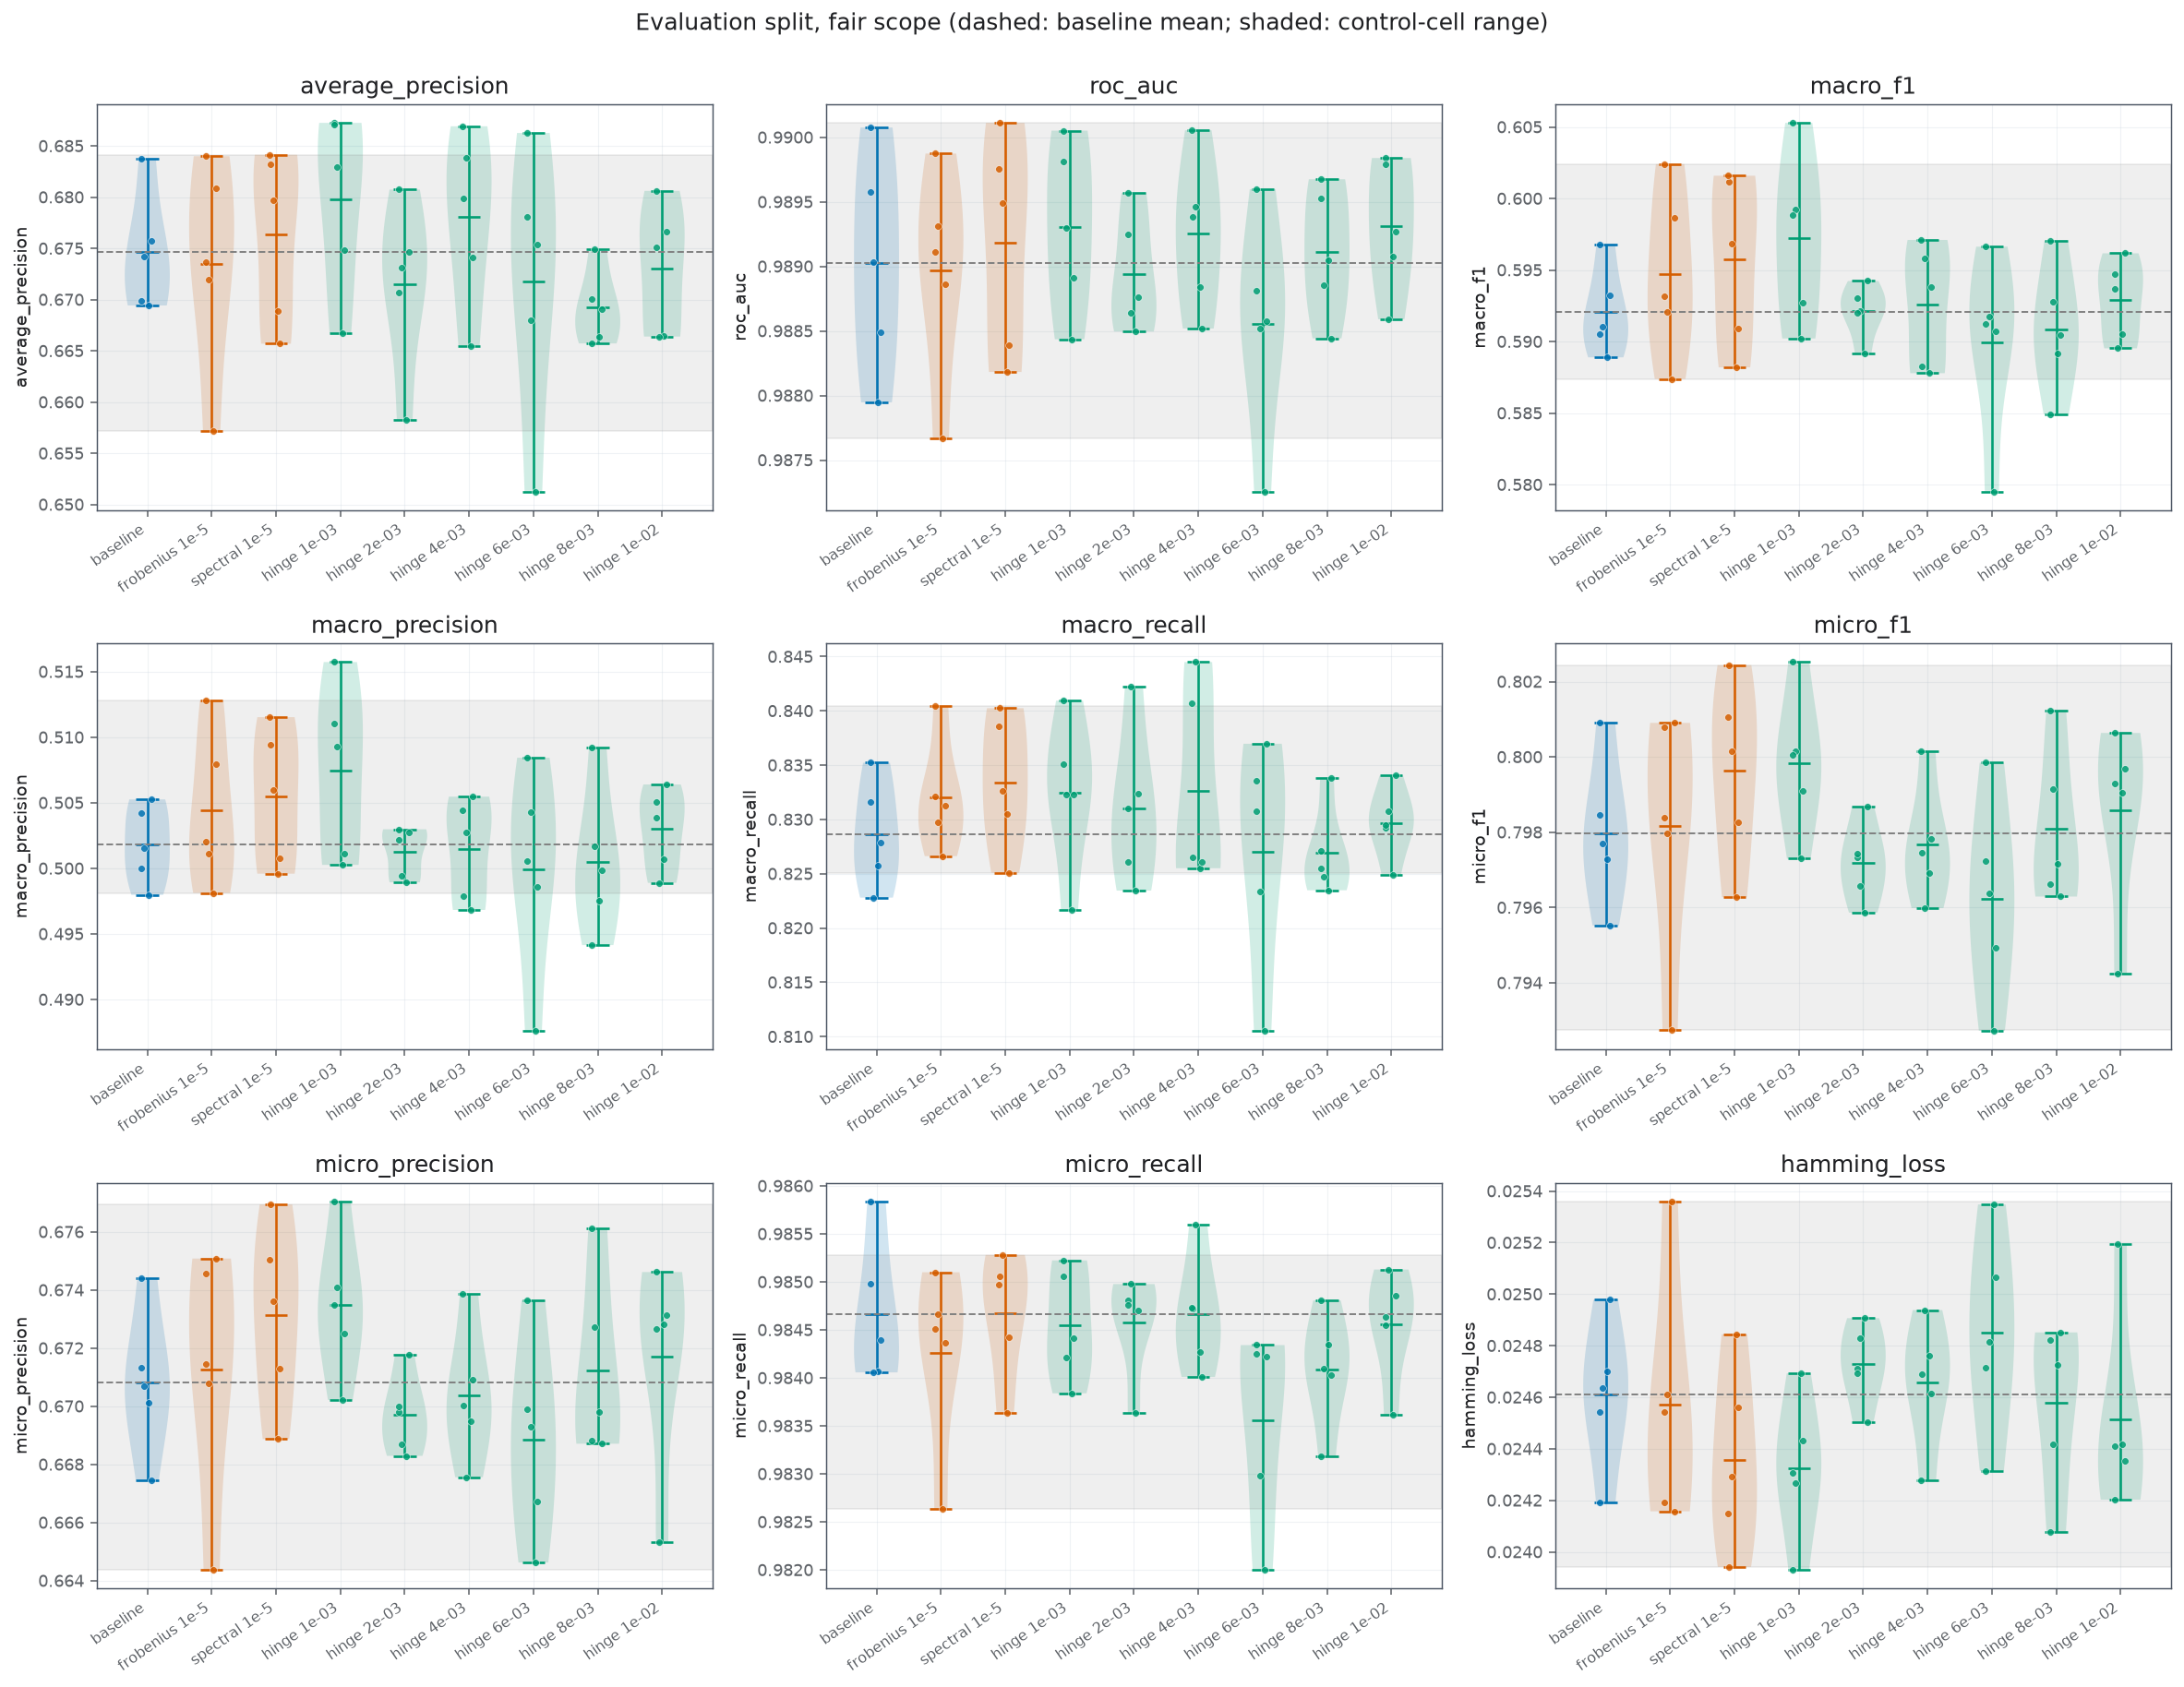

In [8]:
def cell_samples(frame, metric, scope=None, split="test", column="value"):
    scope = scope or evaluation.FAIR_SCOPE
    selected = frame.query("metric == @metric and scope == @scope and split == @split")
    return {cell: group[column].dropna().to_numpy() for cell, group in selected.groupby("cell_label")}


def draw_cells(axis, samples, ylabel, title, null_band=True):
    for position, cell in enumerate(SELECTED_CELLS):
        values = samples.get(cell)
        if values is None or not len(values):
            continue
        plot_violin_with_points(
            values, position=position, ax=axis, width=0.7,
            color=CELL_COLOR[cell], point_size=16.0, jitter=0.10, theme=theme,
        )
    if BASELINE_CELL in samples and len(samples[BASELINE_CELL]):
        axis.axhline(float(np.mean(samples[BASELINE_CELL])), color="grey", linestyle="--", linewidth=1)
    if null_band:
        control_values = np.concatenate([samples[cell] for cell in CONTROL_CELLS if cell in samples and len(samples[cell])] or [np.empty(0)])
        if control_values.size:
            axis.axhspan(control_values.min(), control_values.max(), color="grey", alpha=0.12)
    axis.set_xticks(range(len(SELECTED_CELLS)))
    axis.set_xticklabels([SHORT_LABEL[cell] for cell in SELECTED_CELLS], rotation=35, ha="right", fontsize=8)
    axis.set(ylabel=ylabel, title=title)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)


figure, axes = plt.subplots(3, 3, figsize=(17.0, 13.0), dpi=theme.figure_dpi)
for axis, metric in zip(axes.ravel(), METRIC_ORDER):
    draw_cells(axis, cell_samples(prediction_frame, metric), metric, metric)
figure.suptitle("Evaluation split, fair scope (dashed: baseline mean; shaded: control-cell range)", y=1.001, fontsize=13)
figure.tight_layout()

## The hinge weight ladder

### Methodology

#### Theoretical

This is the notebook's primary figure. If the earlier sweep missed an improvement because
its grid was too coarse, the refinement must show average precision rising above the
baseline somewhere strictly inside the interval and returning toward it at the ends. A flat
ladder within the null band is evidence against the coarse-grid reading, and by elimination
strengthens the two remaining explanations `part_3` left open.

Reading a maximum off a ladder selected because it contained the previous best point is
optimistic by construction. The relevant question is therefore not which rung is highest,
but whether any rung's paired interval against the baseline clears zero.

A second, stronger question is whether the rungs differ from each other at all. If the
weight had any effect in this interval, the spread of the rung means would exceed what
seed noise alone produces within a rung. Comparing those two variance components across
the six rungs answers that directly, and it does not depend on the baseline: a ladder whose
between-rung spread is no larger than its within-rung spread carries no weight-dependent
signal, whatever its highest point happens to be.

#### Implementation

Average precision per repetition is plotted against the objective weight on a logarithmic
axis, with the two campaigns distinguished by marker so a discontinuity at the boundary
between them would be visible. The paired contrast against the baseline is computed per
rung with `paired_contrast`, which matches repetitions on their index.

#### Figure descriptions

The printed test reports the variance ratio across the six rungs with its p-value, the
standard deviation of the rung means, and the typical standard deviation within a rung. A
ratio near or below one, with a between-rung spread no larger than the within-rung spread,
means the ladder is flat within this design's resolution.

The left panel plots the objective weight on a logarithmic x-axis against average precision
on the evaluation split in the fair scope; each point is one repetition, filled for rungs
from the new campaign and hollow for the two from the earlier one, with the per-rung mean
joined by a line. The dashed horizontal line is the baseline mean and the shaded band the
control-cell range. The right panel plots the same rungs as paired differences against the
baseline with their 95% intervals as error bars; the horizontal line at zero is the
baseline, a rung whose interval lies entirely above it is an improvement, and a rung whose
interval crosses it is not resolved by this design.

### Remarks

### Notes

ladder: 6 rungs x 5 repetitions
  variance ratio F = 1.131, p = 0.371
  spread of rung means      = 0.0041
  typical spread within rung = 0.0082
  null band (control cells)  = 0.6571 to 0.6841
  ladder means span          = 0.6692 to 0.6798


,cell_label,weight,pairs,mean_difference,ci_low,ci_high,separated_from_zero
0,fisher_rao / frobenius / w=1e-05,0.000,5,-0.0011,-0.0147,0.0125,False
1,fisher_rao / spectral / w=1e-05,0.000,5,0.0017,-0.0094,0.0128,False
2,fisher_rao / spectral_plus_hinged / w=1e-03 / ...,0.001,5,0.0052,-0.0049,0.0152,False
3,fisher_rao / spectral_plus_hinged / w=2e-03 / ...,0.002,5,-0.0031,-0.0090,0.0027,False
4,fisher_rao / spectral_plus_hinged / w=4e-03 / ...,0.004,5,0.0034,-0.0083,0.0152,False
5,fisher_rao / spectral_plus_hinged / w=6e-03 / ...,0.006,5,-0.0028,-0.0184,0.0128,False
6,fisher_rao / spectral_plus_hinged / w=8e-03 / ...,0.008,5,-0.0054,-0.0121,0.0013,False
7,fisher_rao / spectral_plus_hinged / w=1e-02 / ...,0.010,5,-0.0016,-0.0114,0.0082,False


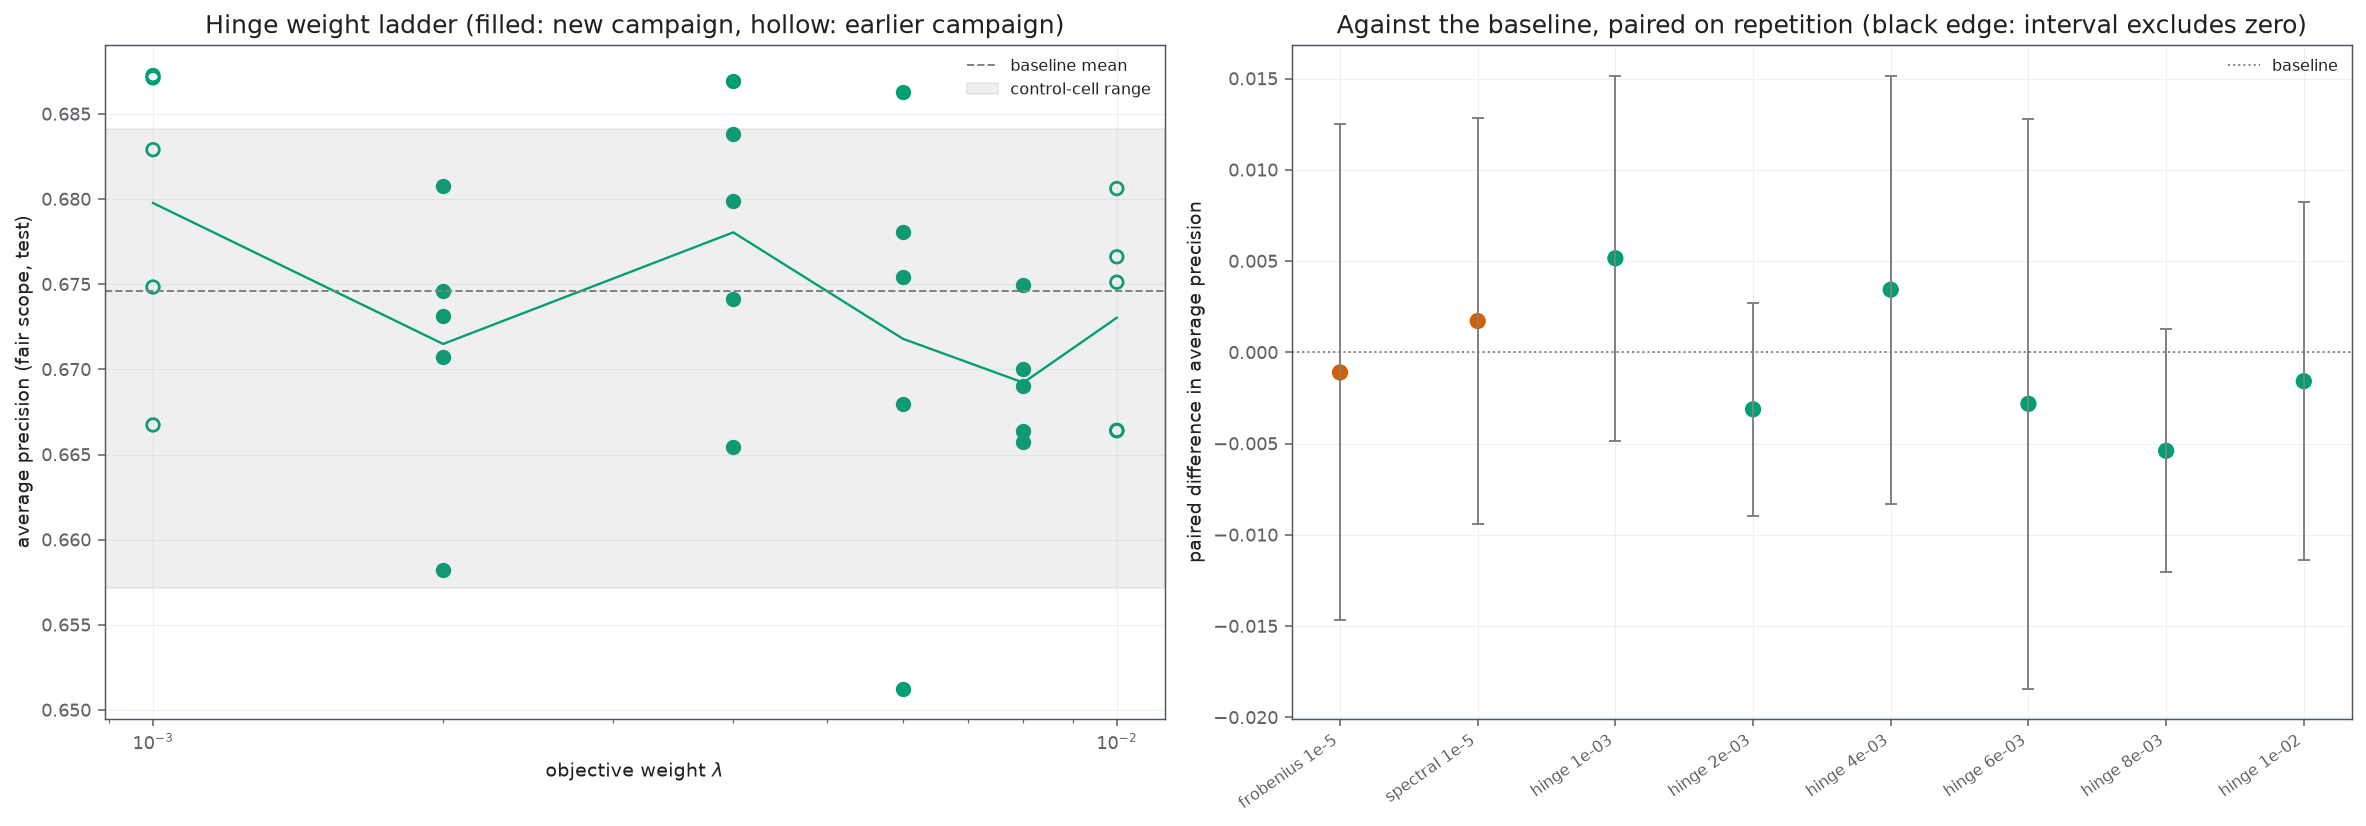

In [9]:
ladder_weights = {cell: float(grid_frame.query("cell_label == @cell").iloc[0]["weight"]) for cell in LADDER_CELLS}
ladder_campaign = {cell: grid_frame.query("cell_label == @cell").iloc[0]["campaign"] for cell in LADDER_CELLS}
ap_samples = cell_samples(prediction_frame, "average_precision")
baseline_mean = float(np.mean(ap_samples[BASELINE_CELL]))
control_values = np.concatenate([ap_samples[cell] for cell in CONTROL_CELLS])

figure, (ladder_axis, contrast_axis) = plt.subplots(1, 2, figsize=(17.0, 6.0), dpi=theme.figure_dpi)
means = []
for cell in LADDER_CELLS:
    weight = ladder_weights[cell]
    values = ap_samples[cell]
    is_new = ladder_campaign[cell] == ACTIVATION_CAMPAIGN
    ladder_axis.scatter(
        np.full(values.shape, weight), values, s=42,
        color=GROUP_COLOR["ladder"] if is_new else "none",
        edgecolor=GROUP_COLOR["ladder"], linewidth=1.4,
    )
    means.append((weight, float(values.mean())))
means.sort()
ladder_axis.plot([w for w, _ in means], [m for _, m in means], color=GROUP_COLOR["ladder"], linewidth=1.2)
ladder_axis.axhline(baseline_mean, color="grey", linestyle="--", linewidth=1, label="baseline mean")
ladder_axis.axhspan(control_values.min(), control_values.max(), color="grey", alpha=0.12, label="control-cell range")
ladder_axis.set_xscale("log")
ladder_axis.set(xlabel=r"objective weight $\lambda$", ylabel="average precision (fair scope, test)", title="Hinge weight ladder (filled: new campaign, hollow: earlier campaign)")
ladder_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
ladder_axis.legend(fontsize=8, frameon=theme.legend_frame)


def repetition_values(frame, cell, metric=None, column="value", scope=None, split="test"):
    selected = frame.query("cell_label == @cell")
    if metric is not None:
        selected = selected.query("metric == @metric")
    if scope is not None:
        selected = selected.query("scope == @scope")
    if split is not None and "split" in selected.columns:
        selected = selected.query("split == @split")
    return {
        int(row.repetition): float(getattr(row, column))
        for row in selected.itertuples()
        if row.repetition is not None and np.isfinite(getattr(row, column))
    }


baseline_repetitions = repetition_values(prediction_frame, BASELINE_CELL, "average_precision", scope=evaluation.FAIR_SCOPE)
contrast_rows = []
for cell in [*CONTROL_CELLS, *LADDER_CELLS]:
    contrast = sweep.paired_contrast(
        repetition_values(prediction_frame, cell, "average_precision", scope=evaluation.FAIR_SCOPE),
        baseline_repetitions,
    )
    contrast_rows.append({"cell_label": cell, "weight": grid_frame.query("cell_label == @cell").iloc[0]["weight"], **contrast})
contrast_frame = pd.DataFrame(contrast_rows)

## Do the rungs differ from each other at all, independently of the baseline?
rung_samples = [np.asarray(ap_samples[cell]) for cell in LADDER_CELLS]
variance_ratio, variance_p_value = stats.f_oneway(*rung_samples)
between_rung_spread = float(np.std([values.mean() for values in rung_samples], ddof=1))
within_rung_spread = float(np.mean([values.std(ddof=1) for values in rung_samples]))
print(f"ladder: {len(rung_samples)} rungs x {len(rung_samples[0])} repetitions")
print(f"  variance ratio F = {variance_ratio:.3f}, p = {variance_p_value:.3f}")
print(f"  spread of rung means      = {between_rung_spread:.4f}")
print(f"  typical spread within rung = {within_rung_spread:.4f}")
print(f"  null band (control cells)  = {control_values.min():.4f} to {control_values.max():.4f}")
print(f"  ladder means span          = {min(v.mean() for v in rung_samples):.4f} to {max(v.mean() for v in rung_samples):.4f}")

plotted = contrast_frame.dropna(subset=["mean_difference"])
positions = np.arange(len(plotted))
contrast_axis.errorbar(
    positions, plotted["mean_difference"],
    yerr=[plotted["mean_difference"] - plotted["ci_low"], plotted["ci_high"] - plotted["mean_difference"]],
    fmt="none", ecolor="grey", elinewidth=1, capsize=3,
)
contrast_axis.scatter(
    positions, plotted["mean_difference"], s=70,
    color=[CELL_COLOR[cell] for cell in plotted["cell_label"]],
    edgecolor=["black" if separated else "none" for separated in plotted["separated_from_zero"]], linewidth=1.4,
)
contrast_axis.axhline(0.0, color="grey", linestyle=":", linewidth=1, label="baseline")
contrast_axis.set_xticks(positions)
contrast_axis.set_xticklabels([SHORT_LABEL[cell] for cell in plotted["cell_label"]], rotation=35, ha="right", fontsize=8)
contrast_axis.set(ylabel="paired difference in average precision", title="Against the baseline, paired on repetition (black edge: interval excludes zero)")
contrast_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
contrast_axis.legend(fontsize=8, frameon=theme.legend_frame)
figure.tight_layout()
display(contrast_frame.round(4))

## Generalization gap along the ladder

### Methodology

#### Theoretical

A regularizer's intended effect is to reduce the gap between training and evaluation
performance without reducing evaluation performance. The gap is computed per repetition,
pairing the two splits of the same run, so the between-seed variance that would otherwise
dominate a five-observation comparison is removed.

#### Implementation

Paired train-minus-test average precision in the fair scope, per repetition, shown as a
distribution per cell.

#### Figure descriptions

One violin per cell showing the distribution over five repetitions of the paired
train-minus-test difference in average precision; zero means identical performance on both
splits and a smaller positive value means less overfitting. The x-axis lists the nine cells
in the fixed order, the dashed line is the baseline mean and the shaded band the control
range.

### Remarks

### Notes

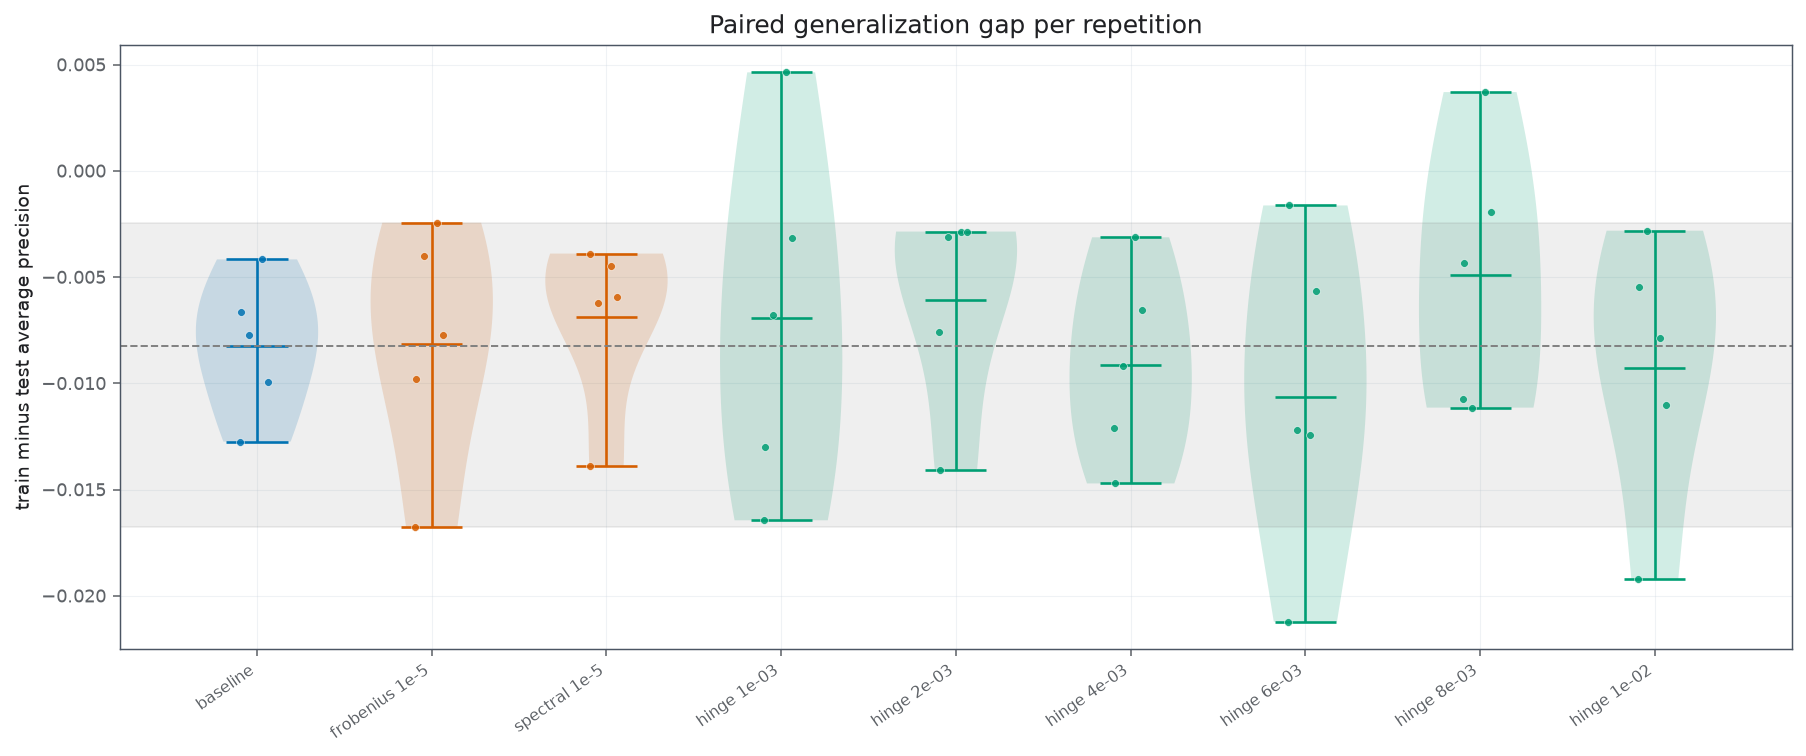

In [10]:
paired = (
    prediction_frame.query("metric == 'average_precision' and scope == @evaluation.FAIR_SCOPE")
    .pivot_table(index=["cell_label", "repetition"], columns="split", values="value")
    .dropna()
)
paired["gap"] = paired["train"] - paired["test"]
gap_samples = {cell: paired.loc[cell, "gap"].to_numpy() for cell in SELECTED_CELLS if cell in paired.index.get_level_values("cell_label")}

figure, ax = plt.subplots(figsize=(13.0, 5.5), dpi=theme.figure_dpi)
draw_cells(ax, gap_samples, "train minus test average precision", "Paired generalization gap per repetition")
figure.tight_layout()

## Latent geometry over the same cells

### Methodology

#### Theoretical

`part_2` established that the Fisher-Rao geometry preserves latent variation where the
Euclidean one destroys it, and that exploding angular sensitivity coincides with a collapsed
trace. The ladder sits inside the weight region where that preservation held, so the
geometry check here is a guard rather than an expected finding: if a rung showed a prediction
gain together with a collapsing trace, the gain would be suspect.

#### Implementation

Statistics come from the same encoding pass as the prediction metrics, computed through
`latent_geometry_frame`. A single deterministic row selection per split is drawn once and
reused for every model, because two of the measures are quadratic in the row count; sharing
the selection is what keeps the values comparable across cells. Angular sensitivity is measured per
repetition with isotropic perturbations in the ambient input space, deliberately not in the
trained geometry, since using the trained geometry would make the comparison circular.

#### Figure descriptions

The first grid shows one panel per latent statistic named in the title, with one violin per
cell over its five repetitions, the baseline mean as a dashed line and the control range
shaded. Trace measures retained variation, effective rank and participation ratio how it is
spread over directions, and cloud asymmetry how far the cloud sits off center. The second
figure plots relative perturbation size on a logarithmic x-axis against mean angular
displacement in degrees, one thin line per repetition colored by group, with the
distribution at the largest perturbation shown as violins beside it; lower displacement
means a less sensitive encoder.

### Remarks

### Notes

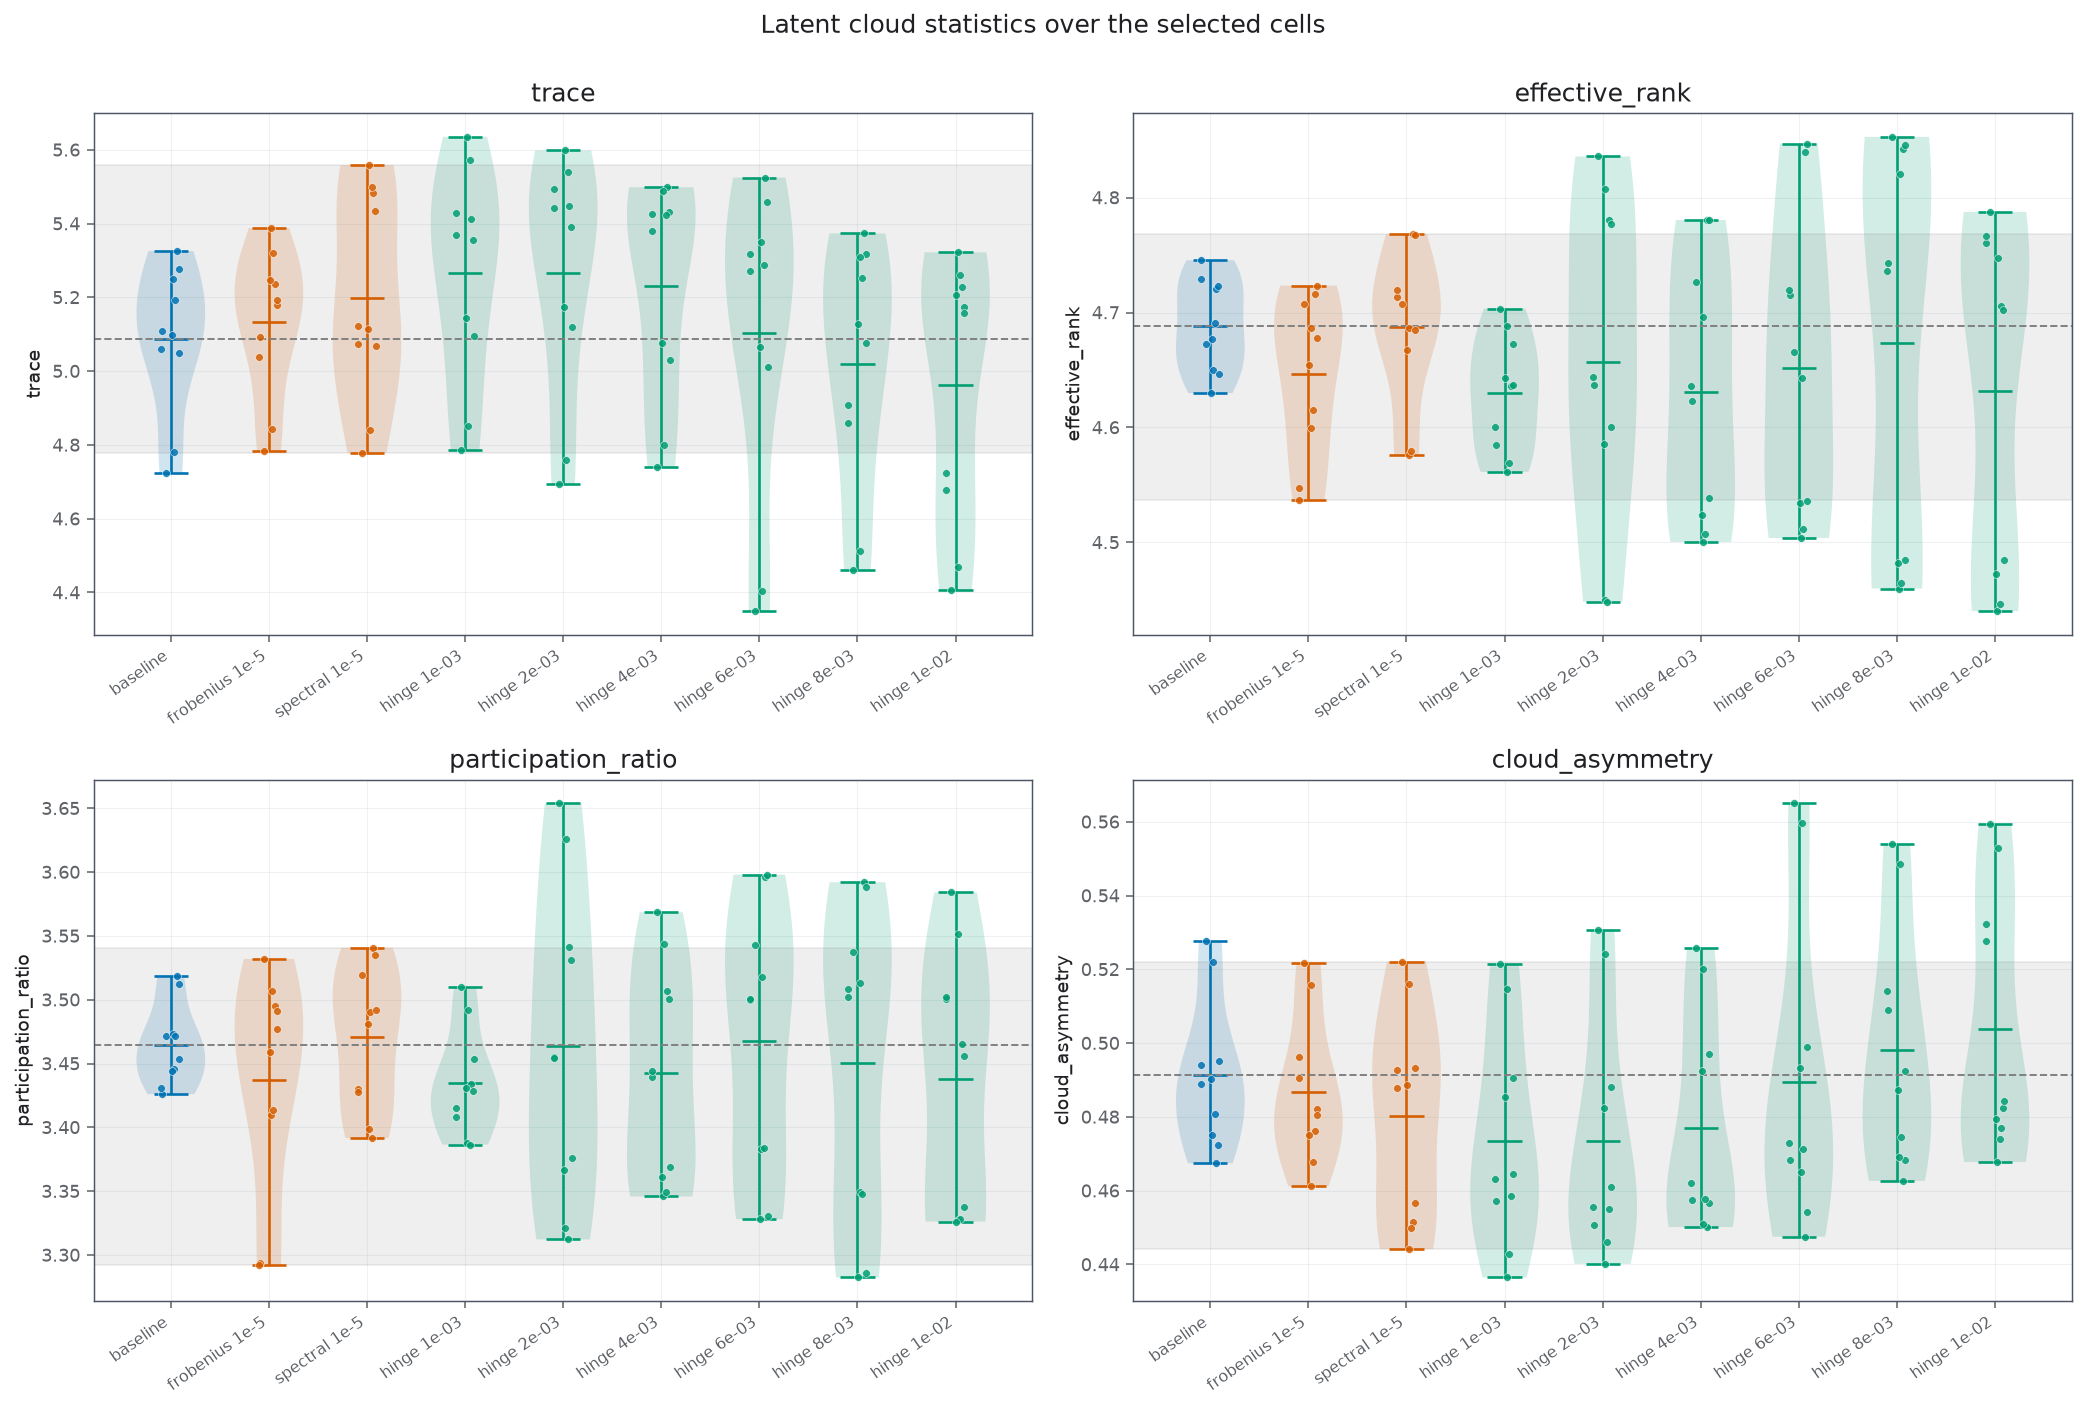

In [11]:
GEOMETRY_METRICS = ["trace", "effective_rank", "participation_ratio", "cloud_asymmetry"]
figure, axes = plt.subplots(2, 2, figsize=(15.0, 10.0), dpi=theme.figure_dpi)
for axis, metric in zip(axes.ravel(), GEOMETRY_METRICS):
    selected = geometry_frame.query("metric == @metric").dropna(subset=["value"])
    samples = {cell: group["value"].to_numpy() for cell, group in selected.groupby("cell_label")}
    draw_cells(axis, samples, metric, metric)
figure.suptitle("Latent cloud statistics over the selected cells", y=1.001, fontsize=13)
figure.tight_layout()

2026-09-07 17:43:59,691 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-07 17:43:59,691 | INFO     | msi_autoencoder_wrapper.models.model_loader:68 | Reconstructing loaded model family 'autoencoder'.


2026-09-07 17:43:59,692 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:173 | Initializing multi-component sub-graph resolution phase for model family: autoencoder


2026-09-07 17:43:59,692 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='encoder' using Strategy='CNNEncoder'.


2026-09-07 17:43:59,697 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='decoder' using Strategy='CNNDecoder'.


...

2026-09-07 17:44:46,000 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:217 | Instantiating nested sub-module: Collection='heads', Key='molecule_primary' using Strategy='LinearClassificationHead'.


2026-09-07 17:44:46,002 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-09-07 17:44:46,002 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-09-07 17:44:46,005 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-07 17:44:46,009 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


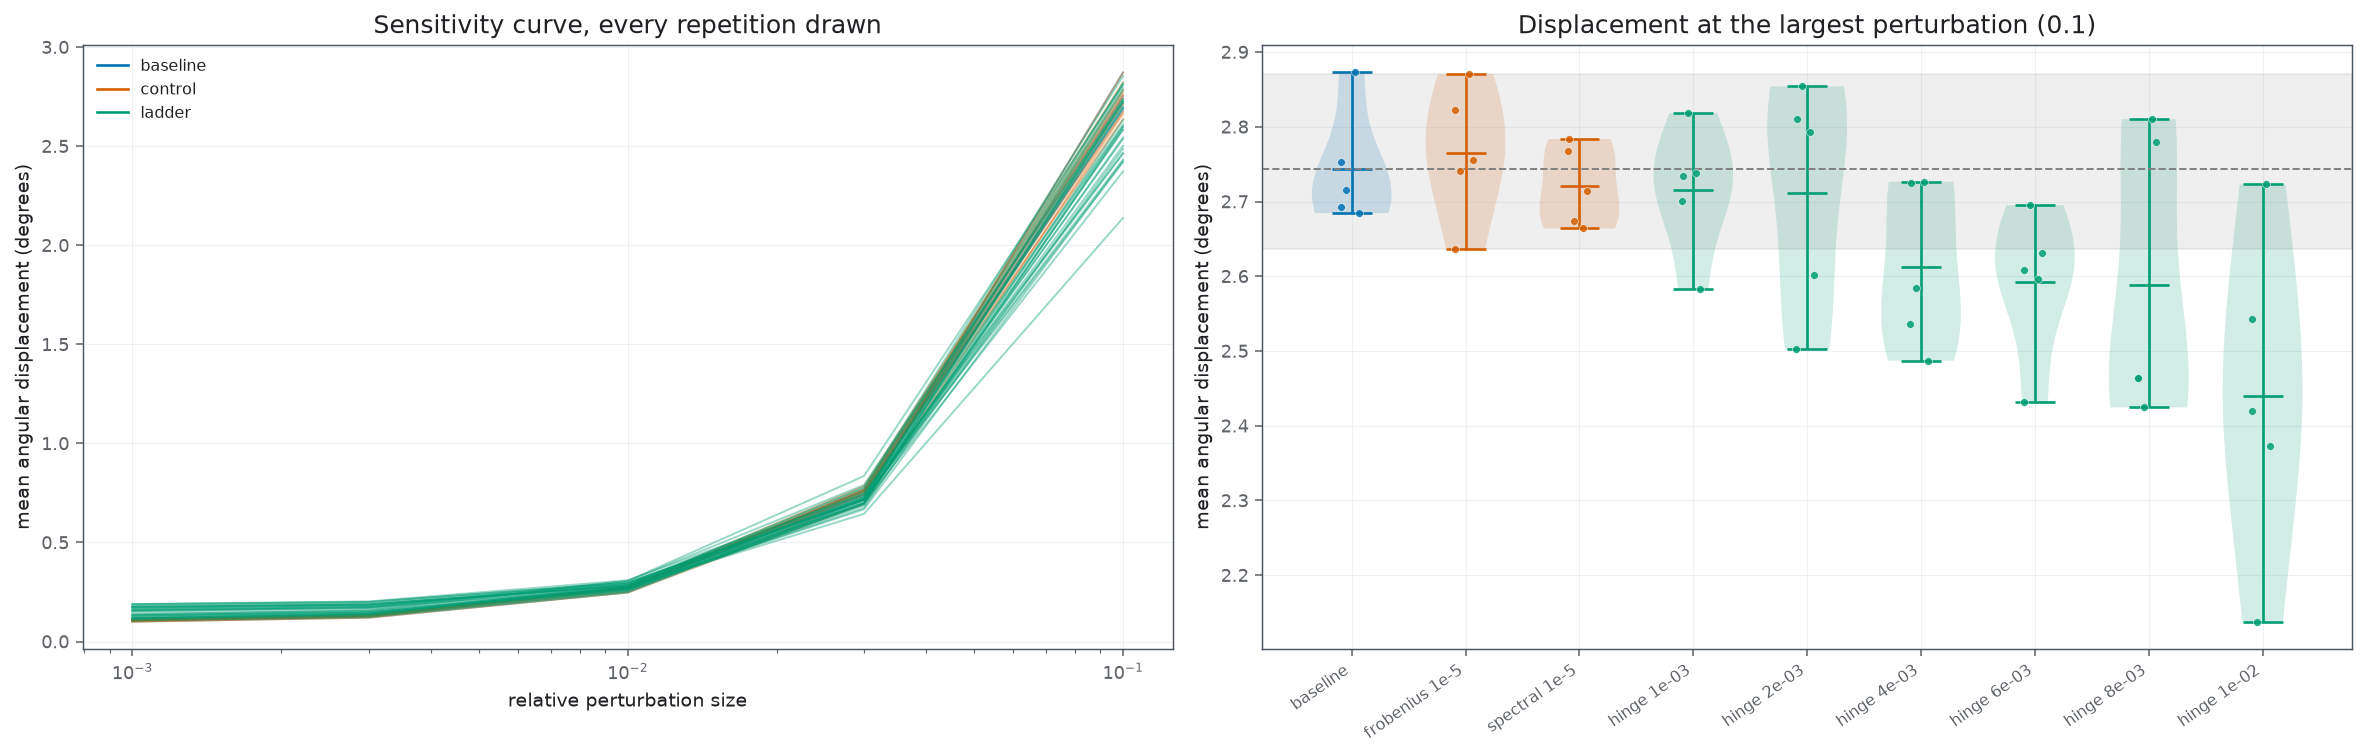

In [12]:
sensitivity_rng = np.random.default_rng(SAMPLE_SEED + 3)
sensitivity_inputs = splits["test"].spectra.numpy()
sensitivity_rows = []
for record in grid_frame.to_dict("records"):
    model = load_model(record["model_name"])
    model.eval()
    gamma, beta = geometry.encoder_layer_norm_parameters(model)

    def encode(batch: np.ndarray) -> np.ndarray:
        with torch.no_grad():
            device = next(model.parameters()).device
            latent = model(torch.as_tensor(batch, dtype=torch.float32).to(device))["latent_space"]
        return geometry.canonicalize(latent.cpu().numpy(), gamma, beta)

    curve = geometry.angular_sensitivity_curve(encode, sensitivity_inputs, EPSILONS, sensitivity_rng)
    for epsilon, angle in zip(curve["epsilon"], curve["mean_angle_degrees"]):
        sensitivity_rows.append({
            "cell_label": record["cell_label"], "campaign": record["campaign"],
            "weight": record["weight"], "repetition": record["repetition"],
            "epsilon": float(epsilon), "mean_angle_degrees": float(angle),
        })
sensitivity_frame = pd.DataFrame(sensitivity_rows)

largest = sensitivity_frame["epsilon"].max()
figure, (curve_axis, level_axis) = plt.subplots(1, 2, figsize=(17.0, 5.5), dpi=theme.figure_dpi)
for (cell, repetition), run in sensitivity_frame.groupby(["cell_label", "repetition"]):
    run = run.sort_values("epsilon")
    curve_axis.plot(run["epsilon"], run["mean_angle_degrees"], color=CELL_COLOR[cell], alpha=0.4, linewidth=1.0)
curve_axis.set_xscale("log")
curve_axis.set(xlabel="relative perturbation size", ylabel="mean angular displacement (degrees)", title="Sensitivity curve, every repetition drawn")
curve_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
handles = [plt.Line2D([], [], color=color, label=name) for name, color in GROUP_COLOR.items()]
curve_axis.legend(handles=handles, fontsize=8, frameon=theme.legend_frame)

at_largest = sensitivity_frame.query("epsilon == @largest")
draw_cells(
    level_axis,
    {cell: group["mean_angle_degrees"].to_numpy() for cell, group in at_largest.groupby("cell_label")},
    "mean angular displacement (degrees)", f"Displacement at the largest perturbation ({largest:g})",
)
figure.tight_layout()

## Cross-seed reproducibility

### Methodology

#### Theoretical

Two configurations can reach the same average precision while one finds a reproducible
representation and the other a different one on every seed. `part_2` found that no penalty
improved reproducibility over the baseline, and that Euclidean spectral destroyed it. The
ladder is checked for the same property, since a rung that improved prediction while
degrading reproducibility would be a poor choice regardless of its mean.

#### Implementation

Every unordered pair of a cell's five repetitions is compared, giving ten pairs per cell.
Row alignment across repetitions holds because every model encodes the identical decoded
split in the identical order. Procrustes distance, linear centered kernel alignment and
neighborhood overlap all come from `sphere_geometry` and are invariant to the rotations the
latent is only defined up to.

#### Figure descriptions

Three panels, one per measure named in the title, with one violin per cell over its ten
repetition pairs and each pair drawn as a point. Lower Procrustes distance and higher kernel
alignment or neighborhood overlap mean a more reproducible representation. The dashed line
is the baseline mean and the shaded band the control range.

### Remarks

### Notes

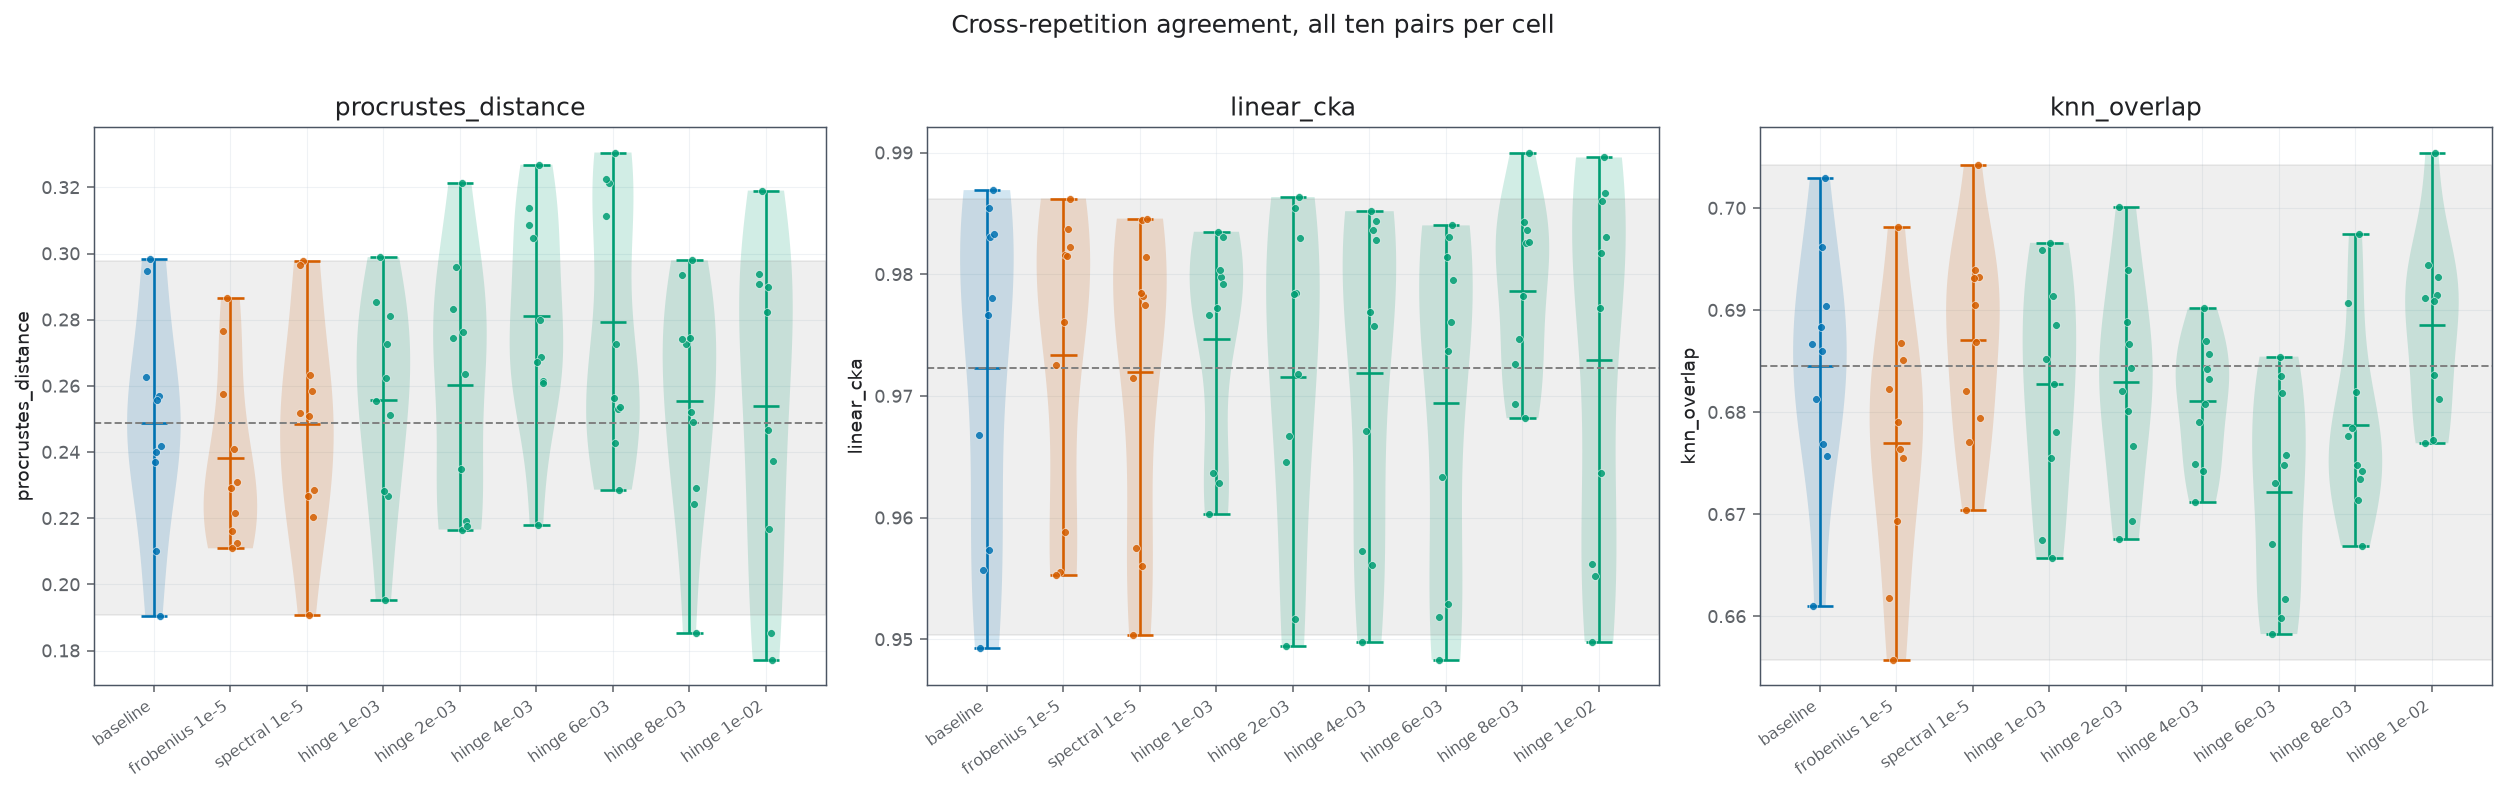

In [13]:
cell_by_label, campaign_by_label = {}, {}
for record in grid_frame.to_dict("records"):
    label = record["cell_label"]
    if label in cell_by_label:
        continue
    cell_by_label[label] = sweep.PenaltySweepCell(
        penalty_metric=record["penalty_metric"], input_geometry=record["input_geometry"],
        weight=record["weight"], hinge_threshold=record["hinge_threshold"],
        hinge_alpha=record["hinge_alpha"], penalized_space=record["penalized_space"],
        calculation_method=record["calculation_method"],
    )
    campaign_by_label[label] = record["campaign"]

stability_rows = []
for (cell_label, split_name), latents in latent_by_cell.items():
    if len(latents) < 2 or split_name != "test":
        continue
    stability_rows += evaluation.representation_stability_frame(
        latents, cell_by_label[cell_label], split_name=split_name,
        campaign=campaign_by_label[cell_label], knn_neighbors=KNN_NEIGHBORS,
    )
stability_frame = pd.DataFrame(stability_rows)

STABILITY_METRICS = ["procrustes_distance", "linear_cka", "knn_overlap"]
figure, axes = plt.subplots(1, 3, figsize=(18.0, 5.5), dpi=theme.figure_dpi)
for axis, metric in zip(axes, STABILITY_METRICS):
    selected = stability_frame.query("metric == @metric")
    samples = {cell: group["value"].to_numpy() for cell, group in selected.groupby("cell_label")}
    draw_cells(axis, samples, metric, metric)
figure.suptitle("Cross-repetition agreement, all ten pairs per cell", y=1.02, fontsize=13)
figure.tight_layout()

## Verdict on the refinement

### Methodology

#### Theoretical

The decision criteria are those of `part_3`, restated so this notebook stands alone: a rung
is carried forward if its paired interval on average precision lies strictly above zero, it
retains at least 80% of the baseline's latent trace, and it costs at most 2.5 times the
baseline's epoch time. The first is the substantive criterion; the other two guard against
accepting a gain bought by collapse or at an unusable price.

One addition is specific to this notebook. Because the interval was chosen for containing
the earlier sweep's best point, a rung that clears zero here is a candidate rather than a
result, and the appropriate next step would be an independent confirmation rather than
adoption.

#### Implementation

Contrasts, trace and cost are joined per cell from the tables computed above. No quantity
is recomputed.

#### Figure descriptions

The table lists one row per non-baseline cell with the paired difference and its interval,
retained trace as a fraction of the baseline's, cost multiple, the three criterion flags and
the verdict, ordered by paired difference.

### Remarks

### Notes

In [14]:
MAX_TRACE_LOSS_FRACTION = 0.20
MAX_COST_MULTIPLE = 2.5

geometry_means = geometry_frame.pivot_table(index="cell_label", columns="metric", values="value", aggfunc="mean")
baseline_trace = float(geometry_means.loc[BASELINE_CELL, "trace"])

decision_rows = []
for row in contrast_frame.itertuples():
    cell = row.cell_label
    trace = float(geometry_means.loc[cell, "trace"])
    epoch_seconds = float(duration_summary.loc[cell, "mean_epoch_seconds"])
    retained = trace / baseline_trace
    cost_multiple = epoch_seconds / baseline_epoch_seconds
    beats = bool(row.ci_low is not None and np.isfinite(row.ci_low) and row.ci_low > 0)
    keeps = bool(retained >= 1.0 - MAX_TRACE_LOSS_FRACTION)
    affordable = bool(cost_multiple <= MAX_COST_MULTIPLE)
    decision_rows.append({
        "cell_label": cell, "weight": row.weight,
        "mean_difference": row.mean_difference, "ci_low": row.ci_low, "ci_high": row.ci_high,
        "retained_trace_fraction": retained, "cost_multiple": cost_multiple,
        "beats_baseline": beats, "keeps_variation": keeps, "affordable": affordable,
        "carried_forward": beats and keeps and affordable,
    })
decision_frame = pd.DataFrame(decision_rows).sort_values("mean_difference", ascending=False)
display(decision_frame.round(4))

winners = decision_frame[decision_frame["carried_forward"]]
best = decision_frame.iloc[0]
print(f"cells passing every criterion: {len(winners)} of {len(decision_frame)}")
print(f"best cell: {best.cell_label}")
print(f"  difference {best.mean_difference:+.4f}, interval [{best.ci_low:+.4f}, {best.ci_high:+.4f}]")
print(f"  retained trace {best.retained_trace_fraction:.3f}, cost {best.cost_multiple:.2f}x baseline")

,cell_label,weight,mean_difference,ci_low,ci_high,retained_trace_fraction,cost_multiple,beats_baseline,keeps_variation,affordable,carried_forward
2,fisher_rao / spectral_plus_hinged / w=1e-03 / ...,0.001,0.0052,-0.0049,0.0152,1.0351,2.1619,False,True,True,False
4,fisher_rao / spectral_plus_hinged / w=4e-03 / ...,0.004,0.0034,-0.0083,0.0152,1.0282,2.2011,False,True,True,False
1,fisher_rao / spectral / w=1e-05,0.000,0.0017,-0.0094,0.0128,1.0218,2.1232,False,True,True,False
0,fisher_rao / frobenius / w=1e-05,0.000,-0.0011,-0.0147,0.0125,1.0091,3.1838,False,True,False,False
7,fisher_rao / spectral_plus_hinged / w=1e-02 / ...,0.010,-0.0016,-0.0114,0.0082,0.9757,2.3541,False,True,True,False
5,fisher_rao / spectral_plus_hinged / w=6e-03 / ...,0.006,-0.0028,-0.0184,0.0128,1.0035,2.1871,False,True,True,False
3,fisher_rao / spectral_plus_hinged / w=2e-03 / ...,0.002,-0.0031,-0.0090,0.0027,1.0354,2.2369,False,True,True,False
6,fisher_rao / spectral_plus_hinged / w=8e-03 / ...,0.008,-0.0054,-0.0121,0.0013,0.9869,2.1571,False,True,True,False


cells passing every criterion: 0 of 8
best cell: fisher_rao / spectral_plus_hinged / w=1e-03 / tau=7
  difference +0.0052, interval [-0.0049, +0.0152]
  retained trace 1.035, cost 2.16x baseline


## Reproducible artifacts

### Methodology

#### Implementation

Long-form prediction, geometry, sensitivity, stability, contrast and decision records are
persisted with the decoded split indices and the fair-scope class selection, so every figure
regenerates without rerunning a model. Provenance records the campaigns, the selected cells,
the decision thresholds, library versions, the commit and a hash of the analysis module.

### Remarks

### Notes

In [15]:
frames = {
    "prediction_metrics": prediction_frame,
    "latent_geometry": geometry_frame,
    "angular_sensitivity": sensitivity_frame,
    "representation_stability": stability_frame,
    "baseline_contrasts": contrast_frame,
    "decision_table": decision_frame,
    "duration_summary": duration_summary.reset_index(),
    "ladder_variance_test": pd.DataFrame([{
        "rungs": len(rung_samples), "repetitions_per_rung": len(rung_samples[0]),
        "variance_ratio": float(variance_ratio), "p_value": float(variance_p_value),
        "between_rung_spread": between_rung_spread, "within_rung_spread": within_rung_spread,
    }]),
    "training_health": selected_health,
    "grid": grid_frame,
}
for name, frame in frames.items():
    frame.to_csv(ARTIFACT_DIR / f"{name}.csv", index=False)

pd.DataFrame({
    "split": np.repeat(list(splits), [split.sampled for split in splits.values()]),
    "dataset_index": np.concatenate([split.indices for split in splits.values()]),
}).to_csv(ARTIFACT_DIR / "sample_indices.csv", index=False)
pd.DataFrame({"class_index": np.flatnonzero(fair_mask)}).to_csv(ARTIFACT_DIR / "fair_scope_classes.csv", index=False)

metadata = {
    "campaigns": CAMPAIGNS,
    "selected_cells": SELECTED_CELLS,
    "control_cells": CONTROL_CELLS,
    "ladder_cells": LADDER_CELLS,
    "head": HEAD_NAME,
    "threshold": THRESHOLD,
    "pixel_fraction": PIXEL_FRACTION,
    "sample_seed": SAMPLE_SEED,
    "splits": {name: {"sampled": split.sampled, "total": split.total} for name, split in splits.items()},
    "classes_fair_scope": int(fair_mask.sum()),
    "classes_total": int(fair_mask.size),
    "models_evaluated": int(len(grid_frame)),
    "baseline_epoch_seconds": baseline_epoch_seconds,
    "max_trace_loss_fraction": MAX_TRACE_LOSS_FRACTION,
    "max_cost_multiple": MAX_COST_MULTIPLE,
    "cells_carried_forward": int(decision_frame["carried_forward"].sum()),
    "numpy": np.__version__,
    "torch": torch.__version__,
    "git_commit": subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip(),
    "analysis_sha256": hashlib.sha256(Path("src/msi_autoencoder_wrapper/analysis/autoencoder/experiments/sweep_evaluation.py").read_bytes()).hexdigest(),
}
(ARTIFACT_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2) + "\n")
logger.info("Wrote %s table(s) and provenance to %s", len(frames), ARTIFACT_DIR)
print(sorted(path.name for path in ARTIFACT_DIR.iterdir()))

2026-09-07 17:44:52,051 | INFO     | hinge_activation_refinement:49 | Wrote 10 table(s) and provenance to assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/part_4_hinge_activation_refinement_results


['angular_sensitivity.csv', 'baseline_contrasts.csv', 'decision_table.csv', 'duration_summary.csv', 'fair_scope_classes.csv', 'grid.csv', 'ladder_variance_test.csv', 'latent_geometry.csv', 'metadata.json', 'prediction_metrics.csv', 'representation_stability.csv', 'sample_indices.csv', 'training_health.csv']


## Results / Summary

### LLM

**The refinement closes the explanation it was built to test.** `part_3` left three readings
open for its negative verdict, one of which was that the weight grid might be too coarse
near $\lambda=10^{-3}$. Filling the interval to $10^{-2}$ with four additional weights
produces a flat ladder: across the six rungs the variance ratio is $F=1.13$ at $p=0.37$, the
spread of the rung means is 0.0041, and the typical spread within a rung is 0.0082. The
rungs vary about half as much from each other as five seeds of a single rung vary among
themselves. There is no weight-dependent signal in this interval to have been missed.

**No rung improves on the baseline, and the null band explains why the question was hard.**
The baseline reaches 0.6746 average precision. Rung means run 0.6798, 0.6715, 0.6780,
0.6718, 0.6692 and 0.6730 across $\lambda = 1, 2, 4, 6, 8 \times 10^{-3}$ and $10^{-2}$,
alternating rather than tracing any shape. The two control cells, which earlier notebooks
found indistinguishable from the baseline, span 0.6571 to 0.6841 over their repetitions, and
that band contains every rung mean. No paired interval clears zero and none of the eight
non-baseline cells is carried forward.

**The best value in the whole campaign is still the earlier sweep's $10^{-3}$ rung**, at
+0.0052 with interval $[-0.0049, +0.0152]$. It was the highest point before the refinement
and remains so after it, which is what a maximum drawn from noise does: it does not move
toward a neighbour when the neighbourhood is sampled more densely, and it does not gain
support.

**Latent geometry stays intact everywhere on the ladder**, retaining 97.6% to 103.5% of the
baseline's trace. This is a guard rather than a finding: it confirms that the flat prediction
result is not a collapsed representation being masked, and it reproduces `part_2`'s
conclusion on the new campaign's models independently.

**The two campaigns join without a seam.** The ladder's endpoints come from the earlier
campaign and its interior from the new one, and no discontinuity appears at either junction
in prediction, geometry or cost. The comparability check passes exactly: across the six rungs
every penalty parameter other than the weight takes a single value.

**What this leaves.** Of `part_3`'s three readings, the coarse-grid one is now eliminated.
The remaining two are that the representation is already near the limit this architecture and
head can exploit, and that a contractive penalty's benefit may not be observable in
in-distribution prediction at all. These are not distinguished by any measurement taken here,
and neither is addressed by a further weight sweep. Testing the second would need an
evaluation the penalty is supposed to help with, such as perturbed or shifted inputs, rather
than more points on this axis.

**Caveat on selection.** This interval was chosen because the first sweep's best point fell
in it. A positive result here would have been optimistic and would have needed independent
confirmation. The result is negative, which the selection bias does not weaken.

### Person